<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part I · Foundations &nbsp;|&nbsp; Chapter 4</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Types of Data &amp; Variables <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:710px;line-height:1.6">Four hands-on demos: identify data types in a real table, pick the right chart for each, tell discrete from continuous, and spot the variable roles behind cause and effect (including a sneaky confounder).</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Concept |
|---|------|---------|
| 1 | Classify the columns of a dataset | **Qualitative vs quantitative** |
| 2 | Pick the right chart for each type | **Bar chart vs histogram** |
| 3 | Counts vs measurements | **Discrete vs continuous** |
| 4 | Cause, effect &amp; a confounder | **Variable roles** (IV / DV / confounder) |
| 5 | Binning a continuous variable | **Transforming** continuous → categorical |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"
GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":15,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
def titlecard(ax, title, subtitle=None):
    ax.set_title(title, loc="left", pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10.5, color=INK_SOFT, va="bottom")
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · QUALITATIVE vs QUANTITATIVE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🏷️ What kind of data is each column?</div>
<div style="color:#4a5578;margin-top:6px">Before any analysis, know your data types, they decide which charts, stats, and models you can use.</div>
</div>

In [2]:
people = pd.DataFrame({
    "name":         ["Ana","Ben","Cara","Dan","Eve","Finn"],
    "gender":       ["F","M","F","M","F","M"],
    "satisfaction": ["High","Low","Medium","High","Medium","Low"],
    "num_pets":     [0, 2, 1, 3, 0, 1],
    "height_cm":    [166.2, 178.5, 160.0, 182.3, 171.1, 175.9],
})
print(people)
print("\nWhat pandas sees (dtypes):")
print(people.dtypes)

   name gender satisfaction  num_pets  height_cm
0   Ana      F         High         0      166.2
1   Ben      M          Low         2      178.5
2  Cara      F       Medium         1      160.0
3   Dan      M         High         3      182.3
4   Eve      F       Medium         0      171.1
5  Finn      M          Low         1      175.9

What pandas sees (dtypes):
name                str
gender              str
satisfaction        str
num_pets          int64
height_cm       float64
dtype: object


In [3]:
# A human-readable classification of each column
classification = pd.DataFrame({
    "column":  ["gender", "satisfaction", "num_pets", "height_cm"],
    "big type":["Qualitative", "Qualitative", "Quantitative", "Quantitative"],
    "subtype": ["Nominal (no order)", "Ordinal (has order)", "Discrete (counts)", "Continuous (measures)"],
    "example value":["F", "High", "2", "178.5"],
})
classification

,column,big type,subtype,example value
0,gender,Qualitative,Nominal (no order),F
1,satisfaction,Qualitative,Ordinal (has order),High
2,num_pets,Quantitative,Discrete (counts),2
3,height_cm,Quantitative,Continuous (measures),178.5


**Key idea:** *qualitative* (categorical) data describe **qualities** (gender, satisfaction); *quantitative* (numerical) data are **numbers you can do math on** (pets, height). Note that `satisfaction` looks like text but has a natural order, that's **ordinal**.

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · THE RIGHT CHART FOR THE TYPE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📊 Bar chart vs histogram</div>
<div style="color:#4a5578;margin-top:6px">Categorical data → bar chart (separate bars). Continuous data → histogram (touching bins). Using the wrong one hides the story.</div>
</div>

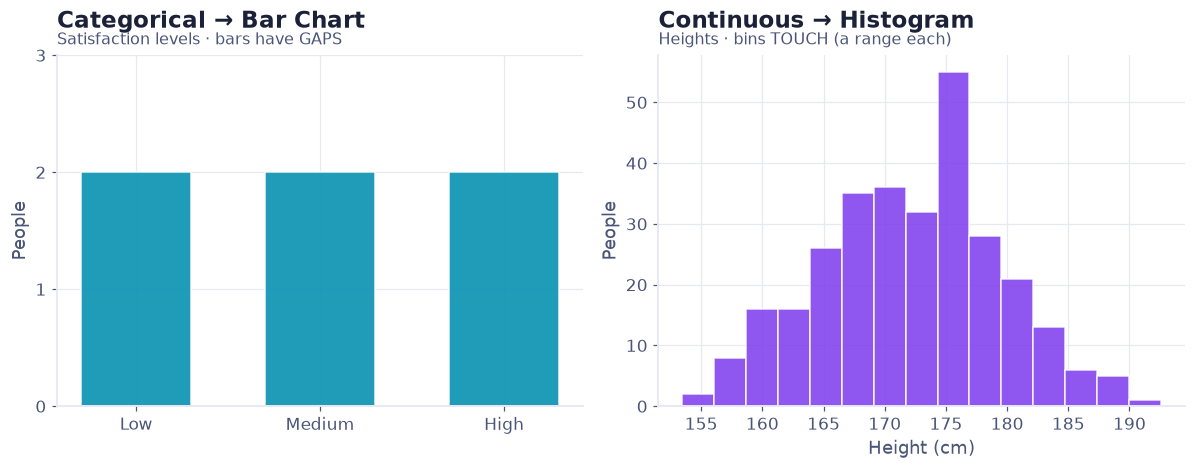

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11,4.4))

# Categorical -> bar chart (count per category)
order = ["Low","Medium","High"]
counts = people["satisfaction"].value_counts().reindex(order)
a1.bar(order, counts.values, color=CYAN, alpha=0.9, edgecolor="white", width=0.6)
titlecard(a1, "Categorical → Bar Chart", "Satisfaction levels · bars have GAPS")
a1.set_ylabel("People"); a1.set_yticks(range(0,4))

# Continuous -> histogram (bins touch)
heights = rng.normal(172, 8, 300)   # a bigger sample to show the shape
a2.hist(heights, bins=15, color=PURPLE, alpha=0.85, edgecolor="white")
titlecard(a2, "Continuous → Histogram", "Heights · bins TOUCH (a range each)")
a2.set_xlabel("Height (cm)"); a2.set_ylabel("People")
plt.tight_layout(); plt.show()

**Spot the difference:** a **bar chart** compares separate categories (gaps between bars); a **histogram** shows the distribution of a continuous number (bars touch because each covers a *range*).

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · DISCRETE vs CONTINUOUS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔢 Counts you can list vs measures you can't</div>
<div style="color:#4a5578;margin-top:6px">Discrete = countable, usually whole numbers (children in a family). Continuous = any value in a range (height, time, temperature).</div>
</div>

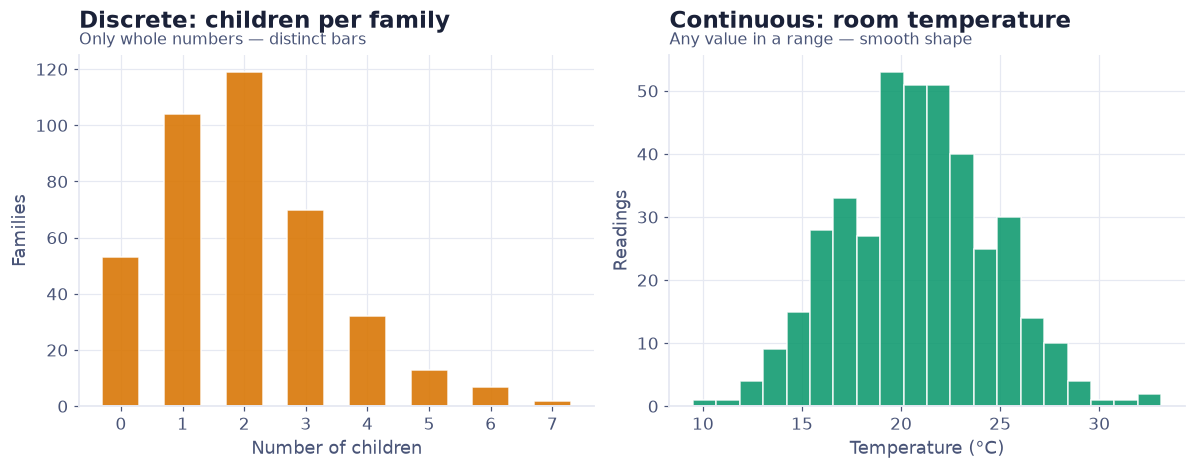

Quick test: can you list every possible value?
  children -> 0,1,2,3,...  YES  -> DISCRETE
  temperature -> 21.0, 21.01, 21.001, ...  NO  -> CONTINUOUS


In [5]:
children = rng.poisson(2, 400)          # discrete: 0,1,2,3,... (you can count them)
temps    = rng.normal(21, 4, 400)       # continuous: 21.3, 18.97, ... (you measure them)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11,4.4))

vals, cnts = np.unique(children, return_counts=True)
a1.bar(vals, cnts, color=AMBER, alpha=0.9, edgecolor="white", width=0.6)
titlecard(a1, "Discrete: children per family", "Only whole numbers — distinct bars")
a1.set_xlabel("Number of children"); a1.set_ylabel("Families"); a1.set_xticks(vals)

a2.hist(temps, bins=20, color=GREEN, alpha=0.85, edgecolor="white")
titlecard(a2, "Continuous: room temperature", "Any value in a range — smooth shape")
a2.set_xlabel("Temperature (°C)"); a2.set_ylabel("Readings")
plt.tight_layout(); plt.show()

print("Quick test: can you list every possible value?")
print("  children -> 0,1,2,3,...  YES  -> DISCRETE")
print("  temperature -> 21.0, 21.01, 21.001, ...  NO  -> CONTINUOUS")

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 4 · VARIABLE ROLES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎯 Cause, effect, and a sneaky confounder</div>
<div style="color:#4a5578;margin-top:6px">The independent variable (IV) is the suspected cause; the dependent variable (DV) is the effect. A confounder secretly drives both and fakes a relationship.</div>
</div>

In [6]:
# Classic example: do ice-cream sales CAUSE drownings? (They don't!)
temperature = rng.uniform(10, 35, 200)               # the hidden CONFOUNDER
ice_cream   = 20 + 6*temperature + rng.normal(0,15,200)   # driven by temperature
drownings   = 1 + 0.30*temperature + rng.normal(0,1.2,200) # ALSO driven by temperature

corr_fake = np.corrcoef(ice_cream, drownings)[0,1]
print(f"Correlation(ice-cream sales, drownings) = {corr_fake:.2f}  <- looks strong!")
print("But neither causes the other — hot weather (temperature) drives BOTH.")

Correlation(ice-cream sales, drownings) = 0.82  <- looks strong!
But neither causes the other — hot weather (temperature) drives BOTH.


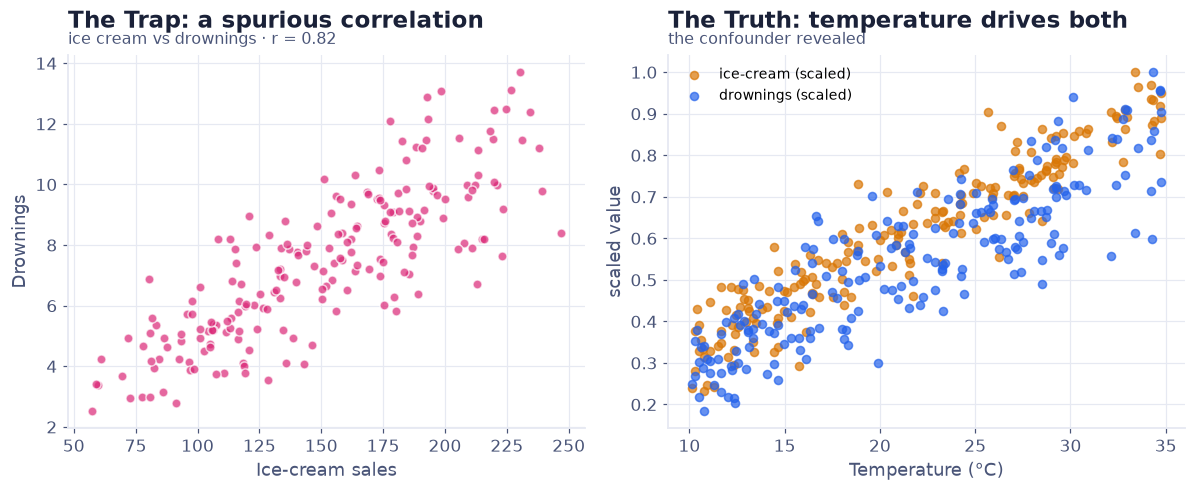

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11,4.6))

# Left: the spurious relationship
a1.scatter(ice_cream, drownings, color=PINK, s=35, alpha=0.7, edgecolor="white")
titlecard(a1, "The Trap: a spurious correlation", f"ice cream vs drownings · r = {corr_fake:.2f}")
a1.set_xlabel("Ice-cream sales"); a1.set_ylabel("Drownings")

# Right: reveal the confounder driving both
a2.scatter(temperature, ice_cream/ice_cream.max(), color=AMBER, s=28, alpha=0.7, label="ice-cream (scaled)")
a2.scatter(temperature, drownings/drownings.max(), color=BLUE, s=28, alpha=0.7, label="drownings (scaled)")
titlecard(a2, "The Truth: temperature drives both", "the confounder revealed")
a2.set_xlabel("Temperature (°C)"); a2.set_ylabel("scaled value"); a2.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Variable roles in one line:** IV = suspected cause, DV = measured effect, **confounder** = a hidden third variable that influences both. Spotting confounders is why "correlation ≠ causation", a theme we revisit in the Correlation chapter.

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 5 · TRANSFORMING DATA TYPES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📦 Binning: continuous → categorical</div>
<div style="color:#4a5578;margin-top:6px">A variable's type is not fixed. A common move is to group a continuous variable into ordered categories (bins).</div>
</div>

Binning turns a continuous variable into ordinal categories:
18-29     53
30-44    153
45-59     80
60+       14


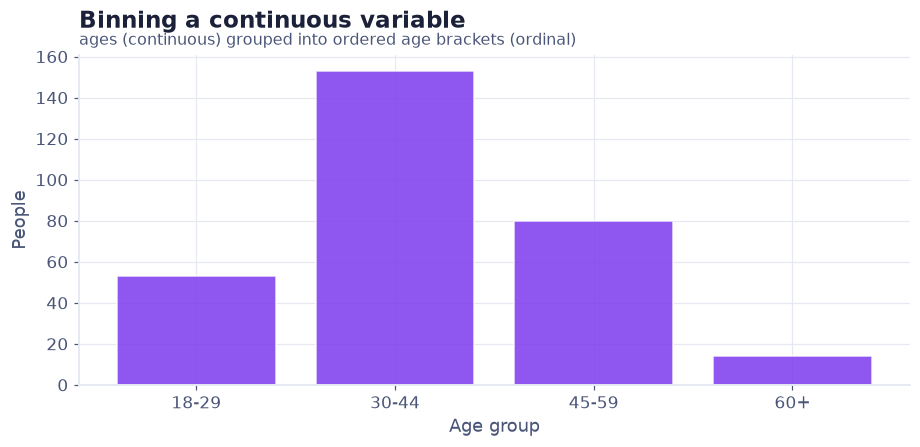

In [8]:
# A continuous variable: ages
ages = rng.normal(38, 12, 300).clip(18, 80)

# Bin it into ordered categories (continuous -> ordinal)
bins   = [18, 30, 45, 60, 81]
labels = ["18-29", "30-44", "45-59", "60+"]
age_group = pd.cut(ages, bins=bins, labels=labels, right=False)

counts = age_group.value_counts().reindex(labels)
print("Binning turns a continuous variable into ordinal categories:")
print(counts.to_string())

fig, ax = plt.subplots(figsize=(8.5,4.2))
ax.bar(labels, counts.values, color=PURPLE, alpha=0.85, edgecolor="white")
titlecard(ax, "Binning a continuous variable", "ages (continuous) grouped into ordered age brackets (ordinal)")
ax.set_xlabel("Age group"); ax.set_ylabel("People")
plt.tight_layout(); plt.show()

**Takeaway:** binning trades detail for simplicity. Ages (continuous) become age brackets (ordinal), handy for charts and some models, but you lose the exact values, so bin on purpose, not by habit.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Qualitative</b> (nominal/ordinal) describes qualities; <b>quantitative</b> (discrete/continuous) is numbers.</li>
<li><b>Bar charts</b> are for categories (gaps); <b>histograms</b> are for continuous data (touching bins).</li>
<li><b>Discrete</b> = countable whole numbers; <b>continuous</b> = any value in a range.</li>
<li><b>Variable roles:</b> independent (cause) → dependent (effect), with confounders lurking in between.</li>
<li><b>Data type decides everything downstream</b>, the chart, the statistic, and the model you may use.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>